# 02. 因子分析に基づく米国債キャリーロールダウン戦略
宮崎浩一・阿部友樹・島田和裕（GPIF, 2021年12月27日）の再現実装

## 概要
- **第2章**: キャリーロールダウン(CA&RD)戦略の実装と検証
- **第3章**: 3ファクターモデルの推定
- **第4章**: 因子分析を組み込んだ改良CA&RD戦略

**論文の目的**: 米国債13セクターを対象に、(1)キャリーロールダウン(CA&RD)戦略と、(2)3ファクターモデルの誤差項を組み込んだ改良CA&RD戦略を実装・比較する。

## セットアップ

必要なライブラリをインポートし、データを読み込む。また、論文の設定値（定数）を定義する。

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline
from scipy.optimize import linprog
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import japanize_matplotlib

from performance import (
    annualize_return,
    calc_tracking_error,
    calc_information_ratio,
    calc_win_rate,
    performance_summary,
)

# ---- 定数定義 ----
MATURITIES   = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 30]
SECTOR_NAMES = ["1Y","2Y","3Y","4Y","5Y","6Y","7Y","8Y","9Y","10Y","15Y","20Y","30Y"]
N_SECTORS    = 13
HOLDING      = 0.5   # 半年保有
GAMMA        = 0.5   # 誤差項修正割合（論文設定値）

IN_SAMPLE_START  = "2017-04-30"
IN_SAMPLE_END    = "2019-03-31"
OUT_SAMPLE_START = "2019-03-31"
OUT_SAMPLE_END   = "2021-10-31"

# ---- データ読み込み ----
df = pd.read_excel(
    "../data/us_treasury_yields.xlsx",
    sheet_name="yields",
    index_col=0,
    parse_dates=True,
)
df.index = pd.to_datetime(df.index)
df.columns = SECTOR_NAMES

print(f"データ期間: {df.index[0].date()} ～ {df.index[-1].date()}")
print(f"形状: {df.shape}")
display(df.head())

データ期間: 2015-01-31 ～ 2021-10-31
形状: (82, 13)


,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y,15Y,20Y,30Y
2015-01-31,0.18,0.47,0.77,0.999077,1.18,1.348691,1.49,1.583768,1.640884,1.68,1.865311,2.04,2.25
2015-02-28,0.22,0.63,1.01,1.290595,1.50,1.678871,1.82,1.910685,1.964127,2.00,2.186838,2.38,2.60
2015-03-31,0.26,0.56,0.89,1.156625,1.37,1.557251,1.71,1.816596,1.887805,1.94,2.150271,2.31,2.54
2015-04-30,0.24,0.58,0.91,1.192696,1.43,1.630466,1.79,1.905034,1.986746,2.05,2.303712,2.49,2.75
2015-05-31,0.26,0.61,0.94,1.235599,1.49,1.698853,1.86,1.974751,2.056109,2.12,2.400876,2.63,2.88


---
## 第2章: キャリーロールダウン戦略

### 2-1: 債券価格関数の定義と検証

論文付録の式(A.1)・(A.2)に基づき、**パーボンド**（額面100円）の価格を計算する関数を定義する。

$$P_{0,T}(y_{\text{coupon}}, y_{\text{discount}}) = \sum_{k=1}^{n} \frac{C/2}{\left(1+\frac{y_{\text{discount}}}{2}\right)^k} + \frac{100}{\left(1+\frac{y_{\text{discount}}}{2}\right)^n} \quad (n = 2T) \tag{A.1}$$

**重要な実装上の注意:**
- クーポンレート $C = y_{\text{coupon}} \times 100$ は**現時点の利回りで固定**する（パーボンド仮定）
- 修正デュレーション $dP/dy$ の計算では**割引率のみ**を変化させる（クーポンは固定）
- `price_bond(y, y, T)` はパーボンド価格 = 100
- `price_bond(y_coupon, y+δ, T)` の微分が正しいデュレーション

In [2]:
def price_bond(y_coupon, y_discount, T, freq=2):
    """
    債券価格 P(y_coupon, y_discount, T) — 式(A.1)
    y_coupon:   クーポン決定に使う利回り（小数）
    y_discount: 割引利回り（小数）
    T:          残存年数
    Note:       y_coupon = y_discount のとき P = 100（パーボンド）
    """
    C      = y_coupon * 100
    n      = round(T * freq)
    y_p    = y_discount / freq
    coupon = C / freq
    pv     = sum(coupon / (1 + y_p)**k for k in range(1, n + 1))
    pv    += 100 / (1 + y_p)**n
    return pv


def dP_dy(y_coupon, y_discount, T, freq=2, dy=1e-5):
    """
    dP/dy_discount の数値微分（中心差分）
    クーポンは y_coupon に固定し、割引率のみ変化させる（正しいデュレーション計算）
    """
    p_up = price_bond(y_coupon, y_discount + dy, T, freq)
    p_dn = price_bond(y_coupon, y_discount - dy, T, freq)
    return (p_up - p_dn) / (2 * dy)


def d2P_dy2(y_coupon, y_discount, T, freq=2, dy=1e-4):
    """d2P/dy2 の数値微分（クーポン固定、割引率を変化）"""
    p_up = price_bond(y_coupon, y_discount + dy, T, freq)
    p_0  = price_bond(y_coupon, y_discount,      T, freq)
    p_dn = price_bond(y_coupon, y_discount - dy, T, freq)
    return (p_up - 2 * p_0 + p_dn) / dy**2


def mod_duration(y, T, freq=2):
    """修正デュレーション = -dP/dy / P（正値）。パーボンド (y_coupon=y_discount=y) での値"""
    P  = price_bond(y, y, T, freq)  # = 100 at par
    dP = dP_dy(y, y, T, freq)
    return -dP / P


# ---- 検証 ----
print("=== 債券価格関数の検証 ===")
print(f"{'年限':>4} | {'価格(par)':>10} | {'修正デュレーション':>16}")
print("-" * 38)
for mat in [1, 2, 5, 10, 20, 30]:
    y_test = 0.02
    p  = price_bond(y_test, y_test, mat)
    md = mod_duration(y_test, mat)
    print(f"  {mat:2d}Y | {p:10.6f} | {md:16.4f}")

=== 債券価格関数の検証 ===
  年限 |    価格(par) |        修正デュレーション
--------------------------------------
   1Y | 100.000000 |           0.9852
   2Y | 100.000000 |           1.9510
   5Y | 100.000000 |           4.7357
  10Y | 100.000000 |           9.0228
  20Y | 100.000000 |          16.4173
  30Y | 100.000000 |          22.4775


### 2-2: イールドカーブの可視化

インサンプル期間（2017年4月末〜2019年3月末）とアウトサンプル期間（2019年3月末〜2021年10月末）のイールドカーブ推移を確認する。

インサンプル期間: 2017-04-30 ～ 2019-03-31 (24ヶ月)
アウトサンプル期間: 2019-03-31 ～ 2021-10-31 (32ヶ月)


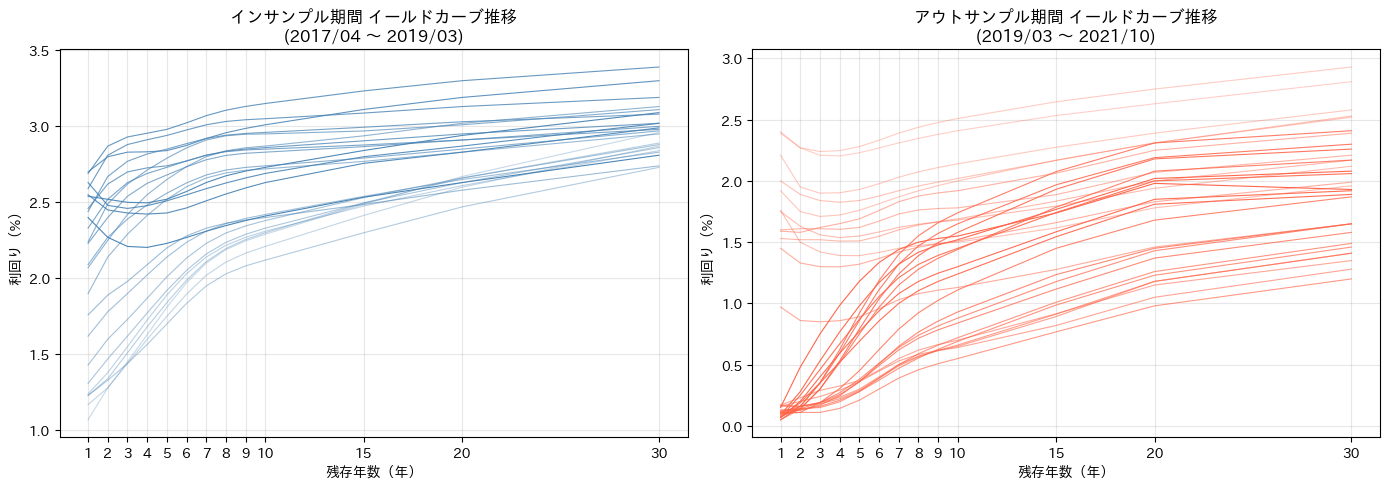

In [3]:
yields_in  = df.loc[IN_SAMPLE_START:IN_SAMPLE_END]
yields_oos = df.loc[OUT_SAMPLE_START:OUT_SAMPLE_END]

print(f"インサンプル期間: {yields_in.index[0].date()} ～ {yields_in.index[-1].date()} ({len(yields_in)}ヶ月)")
print(f"アウトサンプル期間: {yields_oos.index[0].date()} ～ {yields_oos.index[-1].date()} ({len(yields_oos)}ヶ月)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (dt, row) in enumerate(yields_in.iterrows()):
    alpha = 0.3 + 0.7 * i / len(yields_in)
    axes[0].plot(MATURITIES, row.values, color='steelblue', alpha=alpha, linewidth=0.8)
axes[0].set_title('インサンプル期間 イールドカーブ推移\n(2017/04 ～ 2019/03)', fontsize=12)
axes[0].set_xlabel('残存年数（年）'); axes[0].set_ylabel('利回り（%）')
axes[0].set_xticks(MATURITIES); axes[0].grid(True, alpha=0.3)

for i, (dt, row) in enumerate(yields_oos.iterrows()):
    alpha = 0.3 + 0.7 * i / len(yields_oos)
    axes[1].plot(MATURITIES, row.values, color='tomato', alpha=alpha, linewidth=0.8)
axes[1].set_title('アウトサンプル期間 イールドカーブ推移\n(2019/03 ～ 2021/10)', fontsize=12)
axes[1].set_xlabel('残存年数（年）'); axes[1].set_ylabel('利回り（%）')
axes[1].set_xticks(MATURITIES); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2-3: CA&RD計算関数の実装

論文式(3)に基づき、セクターiのキャリーロールダウン（CA&RD）をテーラー展開で計算する。

$$CA\&RD_{T \to T-0.5} \approx \frac{1}{P_0} \left[
\underbrace{\frac{C_T}{2}}_{\text{キャリー}}
+ \underbrace{P'_{T-0.5}(Y_{0,T}) \cdot \Delta y}_{\text{デュレーション項}}
+ \underbrace{\frac{1}{2}P''_{T-0.5}(Y_{0,T}) \cdot (\Delta y)^2}_{\text{コンベキシティ項}}
\right] \tag{3}$$

ここで:
- $\Delta y = Y_{0,T-0.5} - Y_{0,T}$（ロールダウン利回り差、通常は負）
- $P_0 = 100$（パーボンド）
- $P'_{T-0.5}(Y_{0,T})$: $T-0.5$年債価格の微分（**割引率に対して、クーポン固定**）
- $Y_{0,T-0.5}$ はスプライン補間で求める

In [4]:
def calc_card_taylor(y_i, delta_y, T_i, freq=2):
    """
    テーラー展開によるCA&RD計算 — 論文式(3)の汎用版
    y_i:     現在利回り（小数）— クーポン・デリバティブ計算の基準点
    delta_y: 利回り差 = y_rolldown - y_i（小数, 通常は負）
    T_i:     現在年限
    Returns: CA&RD（小数）
    """
    P0   = price_bond(y_i, y_i, T_i, freq)         # パーボンド = 100
    T_rd = max(T_i - HOLDING, MATURITIES[0])
    # P'_{T_rd}(y_i): クーポン固定=y_i、割引率=y_i での T_rd年債価格の微分  # Eq.(3)
    dP1  = dP_dy(y_i, y_i, T_rd, freq)
    d2P1 = d2P_dy2(y_i, y_i, T_rd, freq)
    carry = y_i * 100 / 2                           # C_T/2 キャリー
    rd1   = dP1 * delta_y                           # デュレーション項
    rd2   = 0.5 * d2P1 * delta_y**2                # コンベキシティ項
    return (carry + rd1 + rd2) / P0                 # CA&RD（小数）


def calc_card_all_sectors_basic(yields_row, maturities=MATURITIES, freq=2):
    """
    1時点の利回りベクトルから全セクターのCA&RD（実際利回り使用）を計算。
    yields_row: %単位（例: 2.00 = 2%）
    Returns:    cards (小数), durs
    """
    y_arr = np.array(yields_row.values, dtype=float) / 100  # 小数
    y_pct = np.array(yields_row.values, dtype=float)
    cs    = CubicSpline(maturities, y_pct)
    cards = []
    durs  = []
    for k, T_i in enumerate(maturities):
        y_i     = y_arr[k]
        T_rd    = max(T_i - HOLDING, maturities[0])
        y_rd    = cs(T_rd) / 100
        delta_y = y_rd - y_i
        cards.append(calc_card_taylor(y_i, delta_y, T_i, freq))
        durs.append(mod_duration(y_i, T_i, freq))
    return np.array(cards), np.array(durs)


# ---- 検証: インサンプル最終時点のCA&RD ----
test_row = yields_in.iloc[-1]
cards_test, durs_test = calc_card_all_sectors_basic(test_row)
print(f"検証日: {yields_in.index[-1].date()}")
print(f"{'セクター':>6} | {'CA&RD(%)':>10} | {'修正デュレーション':>18}")
print("-" * 42)
for i, name in enumerate(SECTOR_NAMES):
    print(f"  {name:4s}  | {cards_test[i]*100:10.4f}% | {durs_test[i]:18.4f}")

検証日: 2019-03-31
  セクター |   CA&RD(%) |          修正デュレーション
------------------------------------------
  1Y    |     1.2000% |             0.9823
  2Y    |     1.0539% |             1.9445
  3Y    |     1.0513% |             2.8873
  4Y    |     1.1097% |             3.8087
  5Y    |     1.1823% |             4.7066
  6Y    |     1.2384% |             5.5800
  7Y    |     1.2775% |             6.4292
  8Y    |     1.2967% |             7.2552
  9Y    |     1.3127% |             8.0584
  10Y   |     1.3287% |             8.8392
  15Y   |     1.3980% |            12.4141
  20Y   |     1.4496% |            15.4755
  30Y   |     1.6100% |            20.1797


### 2-4: 単一時点でのCA&RDを可視化

インサンプル最終時点（2019年3月末）のCA&RD値と修正デュレーションをセクター別に棒グラフで表示する。

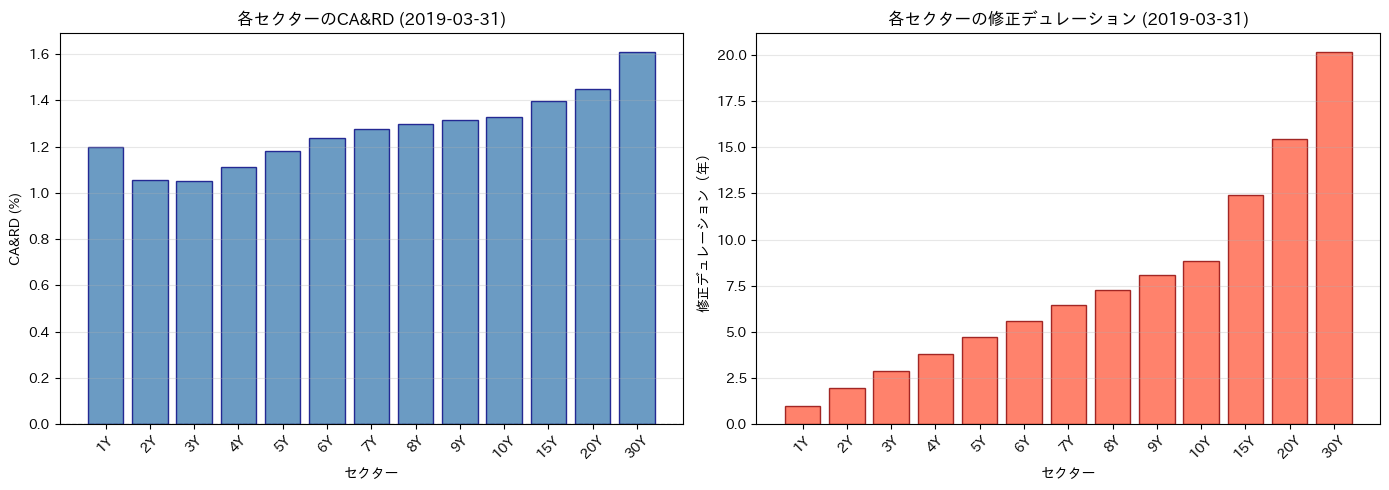

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(SECTOR_NAMES, cards_test * 100, color='steelblue', edgecolor='navy', alpha=0.8)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title(f'各セクターのCA&RD ({yields_in.index[-1].date()})', fontsize=12)
axes[0].set_xlabel('セクター'); axes[0].set_ylabel('CA&RD (%)')
axes[0].tick_params(axis='x', rotation=45); axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(SECTOR_NAMES, durs_test, color='tomato', edgecolor='darkred', alpha=0.8)
axes[1].set_title(f'各セクターの修正デュレーション ({yields_in.index[-1].date()})', fontsize=12)
axes[1].set_xlabel('セクター'); axes[1].set_ylabel('修正デュレーション（年）')
axes[1].tick_params(axis='x', rotation=45); axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 2-5: ベンチマーク設定

論文では FTSE米国国債インデックスをベンチマークとして使用している。本実装では **等加重（各セクター1/13）をベンチマーク近似**として使用する。

$$w_i^M = \frac{1}{N}, \quad D^M = \frac{1}{N} \sum_{i=1}^{N} D_i^M$$

In [6]:
def get_benchmark_weights_and_duration(yields_row, maturities=MATURITIES, freq=2):
    y_arr = np.array(yields_row.values, dtype=float) / 100
    durs  = np.array([mod_duration(y_arr[k], T, freq) for k, T in enumerate(maturities)])
    w_bm  = np.ones(len(maturities)) / len(maturities)
    D_bm  = np.dot(w_bm, durs)
    return w_bm, durs, D_bm


w_bm, durs_bm, D_bm = get_benchmark_weights_and_duration(yields_in.iloc[-1])
print(f"等加重ベンチマーク デュレーション: {D_bm:.4f} 年")
print(f"ベンチマークウエイト (等加重): {w_bm[0]:.4f} × {N_SECTORS}セクター")

等加重ベンチマーク デュレーション: 7.5816 年
ベンチマークウエイト (等加重): 0.0769 × 13セクター


### 2-6: ポートフォリオ最適化関数

論文の最適化モデルを実装する。

$$\max_{w_1, \ldots, w_{13}} \sum_{i=1}^{13} CA\&RD_i \cdot w_i$$

**制約条件:**
1. デュレーション・マッチング: $\sum_i D_i \cdot w_i = D^M$
2. 完全投資: $\sum_i w_i = 1$
3. ロングオンリー: $w_i \geq 0$

`scipy.optimize.linprog` を使用（最小化問題に変換）。

In [7]:
def optimize_portfolio(card_values, durations, bm_duration, n=N_SECTORS):
    c      = -np.array(card_values, dtype=float)   # 最小化 → 符号反転
    A_eq   = np.array([durations, np.ones(n)], dtype=float)
    b_eq   = np.array([bm_duration, 1.0])
    bounds = [(0, 1)] * n
    res    = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')
    if res.success:
        return res.x
    else:
        warnings.warn(f"linprog failed: {res.message}", RuntimeWarning)
        return np.ones(n) / n  # フォールバック


# 検証
w_opt_test = optimize_portfolio(cards_test, durs_test, D_bm)
print(f"最適ウエイト合計: {w_opt_test.sum():.6f}")
print(f"最適デュレーション: {np.dot(w_opt_test, durs_test):.4f} 年")
print(f"ベンチマーク・デュレーション: {D_bm:.4f} 年")
print()
for i, name in enumerate(SECTOR_NAMES):
    bar = '█' * int(w_opt_test[i] * 50)
    print(f"  {name:4s}: {w_opt_test[i]:.4f} {bar}")

最適ウエイト合計: 1.000000
最適デュレーション: 7.5816 年
ベンチマーク・デュレーション: 7.5816 年

  1Y  : 0.6562 ████████████████████████████████
  2Y  : 0.0000 
  3Y  : 0.0000 
  4Y  : 0.0000 
  5Y  : 0.0000 
  6Y  : 0.0000 
  7Y  : 0.0000 
  8Y  : 0.0000 
  9Y  : 0.0000 
  10Y : 0.0000 
  15Y : 0.0000 
  20Y : 0.0000 
  30Y : 0.3438 █████████████████


### 2-7: アウトサンプル期間のバックテスト（月次リバランス）

アウトサンプル期間（2019年3月末〜2021年10月末）に対して月次リバランスのバックテストを実施する。

**実現リターン（式4）:**
$$\tilde{R}_{T \to T-0.5}(t) = \frac{P_{0.5,T-0.5}(Y_{t,T}, \tilde{Y}_{t+1/12, T-0.5}) - P_{0,T}(Y_{t,T}, Y_{t,T})}{P_{0,T}(Y_{t,T}, Y_{t,T})}$$

**先読みバイアス防止:** シグナルは月末$t$のデータのみ使用。実現リターンには翌月末$t+1$の実際の利回りを使用。

In [8]:
def calc_realized_return_sector(y_t, y_t1_rolldown, T_i, freq=2):
    """
    セクターiの1ヶ月保有実現リターン — 式(A.2)に基づく直接計算
    y_t:           時点tの利回り（小数）→ クーポン固定
    y_t1_rolldown: 翌月末の T_i-0.5年利回り（小数）→ 割引
    """
    T_rd   = max(T_i - HOLDING, MATURITIES[0])
    n_rd   = round(T_rd * freq)
    coupon = y_t * 100 / freq                        # クーポン固定
    y_p    = y_t1_rolldown / freq
    P0     = price_bond(y_t, y_t, T_i, freq)         # = 100
    # 式(A.2): P_{0.5, T-0.5} = C/2 + Σ_{k=1}^{n-1} + (C/2+100)/(1+y_p)^n
    P1 = coupon
    P1 += sum(coupon / (1 + y_p)**k for k in range(1, n_rd))
    P1 += (coupon + 100) / (1 + y_p)**n_rd  # 最終クーポン＋元本
    return (P1 - P0) / P0


def run_backtest_basic(df_oos, maturities=MATURITIES, freq=2):
    dates = df_oos.index
    n_p   = len(dates)
    w_list, port_rets, bm_rets = [], [], []

    for t in range(n_p - 1):
        row_t  = df_oos.iloc[t]    # シグナル計算（先読みなし）
        row_t1 = df_oos.iloc[t+1]  # 実現リターン計算（実現値）

        cards_t, durs_t = calc_card_all_sectors_basic(row_t)
        w_bm_t = np.ones(N_SECTORS) / N_SECTORS
        D_bm_t = np.dot(w_bm_t, durs_t)
        w_opt  = optimize_portfolio(cards_t, durs_t, D_bm_t)
        w_list.append(w_opt)

        y_arr_t  = np.array(row_t.values,  dtype=float) / 100
        y_pct_t1 = np.array(row_t1.values, dtype=float)
        cs_t1    = CubicSpline(maturities, y_pct_t1)

        realized = []
        for k, T_i in enumerate(maturities):
            T_rd  = max(T_i - HOLDING, maturities[0])
            y_rd  = cs_t1(T_rd) / 100
            r     = calc_realized_return_sector(y_arr_t[k], y_rd, T_i, freq)
            realized.append(r)
        realized = np.array(realized)

        port_rets.append(np.dot(w_opt,   realized))
        bm_rets.append(np.dot(w_bm_t, realized))

    port_ret = pd.Series(port_rets, index=dates[1:], name='CA&RD(i)')
    bm_ret   = pd.Series(bm_rets,   index=dates[1:], name='BM')
    w_df     = pd.DataFrame(w_list,  index=dates[:-1], columns=SECTOR_NAMES)
    return w_df, port_ret, bm_ret


print("基本CA&RDバックテスト実行中...")
weights_basic, port_ret_basic, bm_ret = run_backtest_basic(yields_oos)
print(f"完了: {len(port_ret_basic)}ヶ月分")

基本CA&RDバックテスト実行中...


完了: 31ヶ月分


### 2-8: パフォーマンス指標の計算と表示

バックテスト結果からパフォーマンス指標（超過リターン・TE・IR・勝率）を計算し、論文の表1と比較する。

=== 基本CA&RD戦略（①）パフォーマンス ===


,値
年率リターン (%),14.103993
超過リターン (%),1.990724
TE (%),0.635516
IR,3.132453
勝率 (%),83.870968


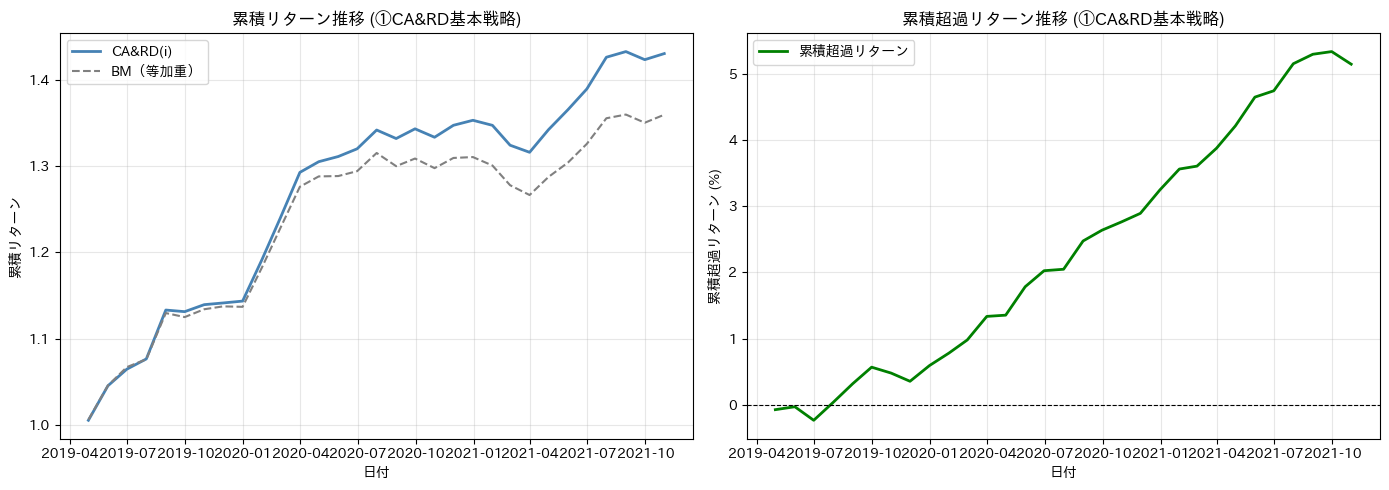

In [9]:
alpha_basic = port_ret_basic - bm_ret
summary_basic = performance_summary(port_ret_basic, bm_ret, periods_per_year=12)
print("=== 基本CA&RD戦略（①）パフォーマンス ===")
display(summary_basic)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cum_port  = (1 + port_ret_basic).cumprod()
cum_bm    = (1 + bm_ret).cumprod()
cum_alpha = (alpha_basic.cumsum() * 100)

axes[0].plot(cum_port.index, cum_port.values, label='CA&RD(i)', color='steelblue', linewidth=2)
axes[0].plot(cum_bm.index,   cum_bm.values,   label='BM（等加重）', color='gray', linestyle='--')
axes[0].set_title('累積リターン推移 (①CA&RD基本戦略)', fontsize=12)
axes[0].set_xlabel('日付'); axes[0].set_ylabel('累積リターン')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(cum_alpha.index, cum_alpha.values, label='累積超過リターン', color='green', linewidth=2)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('累積超過リターン推移 (①CA&RD基本戦略)', fontsize=12)
axes[1].set_xlabel('日付'); axes[1].set_ylabel('累積超過リターン (%)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 第3章: 因子分析

### 3-1: 因子分析の実行（インサンプル期間）

論文式(6)に基づき、インサンプル期間の利回りデータに因子分析を適用する。

$$Y_i(t) = a_{i,1} f_1(t) + a_{i,2} f_2(t) + a_{i,3} f_3(t) + \varepsilon_i(t) \quad (i = 1, \ldots, 13) \tag{6}$$

**重要:** Litterman and Scheinkman [1991] と異なり、本研究では**利回り変化ではなく利回り自体**に因子分析を適用する（目的: セクター間の割高・割安分析）。

In [10]:
yields_in_vals = yields_in.values.astype(float)

scaler = StandardScaler()
yields_scaled = scaler.fit_transform(yields_in_vals)
print(f"インサンプルデータ形状: {yields_in_vals.shape}")
print(f"標準化後 平均≈0: {np.abs(yields_scaled.mean(axis=0)).max():.6f}")

fa = FactorAnalysis(n_components=3, random_state=42, max_iter=1000)
fa.fit(yields_scaled)

# ファクターローディング: sklearn は (n_components, n_features) → 転置して (n_features, n_components)
loadings = fa.components_.T  # shape: (13, 3) = a_{i,j}
print(f"\nファクターローディング 形状: {loadings.shape}")

loading_df = pd.DataFrame(
    loadings,
    index=SECTOR_NAMES,
    columns=['Factor1(Level)', 'Factor2(Slope)', 'Factor3(Curvature)'],
)
display(loading_df.round(4))

インサンプルデータ形状: (24, 13)
標準化後 平均≈0: 0.000000



ファクターローディング 形状: (13, 3)


,Factor1(Level),Factor2(Slope),Factor3(Curvature)
1Y,-0.8561,0.3754,0.3433
2Y,-0.9348,0.2875,0.2057
3Y,-0.9656,0.2272,0.1250
4Y,-0.9814,0.1817,0.0605
5Y,-0.9902,0.1388,0.0083
6Y,-0.9956,0.0908,-0.0204
7Y,-0.9986,0.0453,-0.0260
8Y,-0.9998,0.0126,-0.0167
9Y,-1.0000,-0.0078,0.0023
10Y,-0.9994,-0.0216,0.0255


### 3-2: ファクターローディングの可視化

3ファクターモデルの解釈（論文図3対応）:
- **第1ファクター（水準/Level）**: 全年限でほぼ一定 → パラレルシフト
- **第2ファクター（傾き/Slope）**: 短期高・長期低（またはその逆） → フラットニング/スティープニング
- **第3ファクター（曲率/Curvature）**: 中期が下に凸 → バタフライ運動

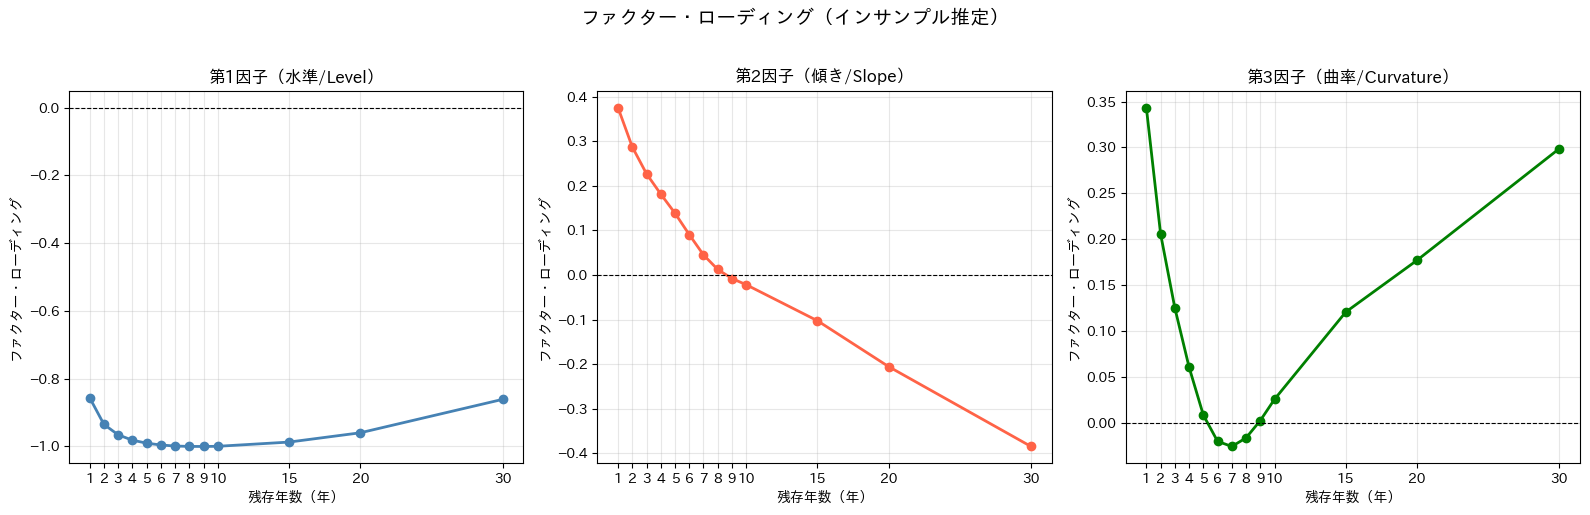

In [11]:
factor_labels = ['第1因子（水準/Level）', '第2因子（傾き/Slope）', '第3因子（曲率/Curvature）']
colors = ['steelblue', 'tomato', 'green']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for j, (label, color) in enumerate(zip(factor_labels, colors)):
    axes[j].plot(MATURITIES, loadings[:, j], 'o-', color=color, linewidth=2, markersize=6)
    axes[j].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[j].set_title(label, fontsize=12)
    axes[j].set_xlabel('残存年数（年）'); axes[j].set_ylabel('ファクター・ローディング')
    axes[j].set_xticks(MATURITIES); axes[j].grid(True, alpha=0.3)

plt.suptitle('ファクター・ローディング（インサンプル推定）', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3-3: 寄与率の確認

3因子モデルが利回り分散の何%を説明できるかを確認する。

$$\text{Var}(Y_i) = \underbrace{\sum_{j=1}^{3} a_{i,j}^2}_{\text{共通性}} + \underbrace{\text{Var}(\varepsilon_i)}_{\text{独自性}}$$

3因子モデルの全体説明率: 99.70%


,共通性（3Fで説明）,独自性（Uniqueness）,説明率(%)
1Y,0.9918,0.0082,99.1758
2Y,0.9987,0.0013,99.8732
3Y,0.9997,0.0003,99.9697
4Y,0.9999,0.0001,99.9851
5Y,0.9999,0.0001,99.9860
6Y,0.9999,0.0001,99.9895
7Y,1.0000,0.0000,99.9991
8Y,1.0000,0.0000,99.9990
9Y,1.0000,0.0000,99.9999
10Y,1.0000,0.0000,99.9968


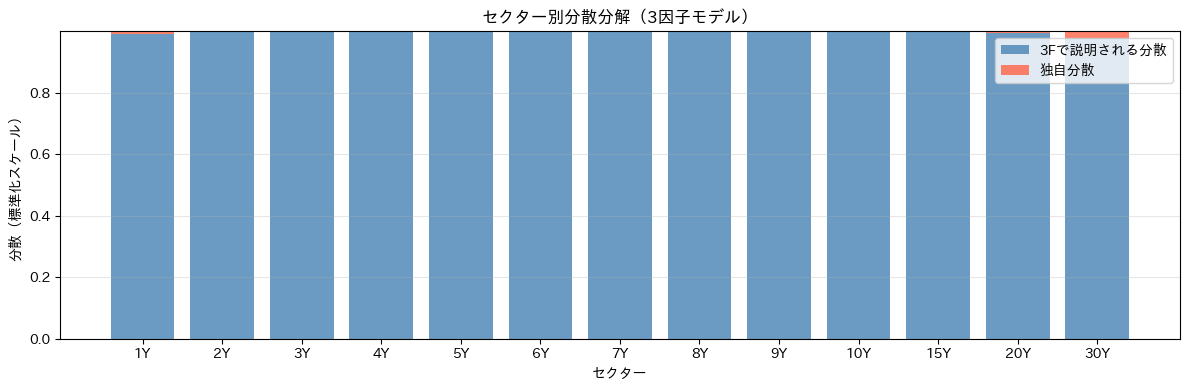

In [12]:
communalities = np.sum(loadings**2, axis=1)
uniqueness    = fa.noise_variance_

explain_pct = np.sum(communalities) / yields_scaled.shape[1] * 100
print(f"3因子モデルの全体説明率: {explain_pct:.2f}%")

var_df = pd.DataFrame({
    '共通性（3Fで説明）': communalities,
    '独自性（Uniqueness）': uniqueness,
    '説明率(%)': communalities / (communalities + uniqueness) * 100,
}, index=SECTOR_NAMES)
display(var_df.round(4))

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(SECTOR_NAMES, communalities, label='3Fで説明される分散', color='steelblue', alpha=0.8)
ax.bar(SECTOR_NAMES, uniqueness, bottom=communalities, label='独自分散', color='tomato', alpha=0.8)
ax.set_title('セクター別分散分解（3因子モデル）', fontsize=12)
ax.set_xlabel('セクター'); ax.set_ylabel('分散（標準化スケール）')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 3-4: アウトサンプルでの誤差項推定

アウトサンプル期間において、インサンプルで推定したローディング $a_{i,j}$ を**固定**し、各月末のイールドカーブデータからクロスセクションOLSでファクター値を推定する。

$$\hat{f}(t) = \arg\min_f \sum_{i=1}^{13} \left(Y_i(t)^{\text{標準化}} - \sum_{j=1}^3 a_{i,j} f_j(t)\right)^2$$

誤差項（%単位）:
$$\varepsilon_i(t) = Y_i(t)^{\text{実際}} - Y_i(t)^{\text{モデル}}$$

$\varepsilon_i > 0$: 割安（実際利回り > 適正水準）、 $\varepsilon_i < 0$: 割高

In [13]:
def estimate_factors_oos(y_t_pct, loadings, scaler):
    """
    クロスセクションOLSでファクター値と誤差項を推定。
    y_t_pct:  時点tの利回りベクトル（%単位）
    loadings: インサンプル推定ローディング (13x3) — 固定
    scaler:   インサンプルのStandardScaler — 固定
    Returns: f_hat（標準化スケール）, residuals（%単位）, y_model_pct（%単位）
    """
    y_scaled = scaler.transform(y_t_pct.reshape(1, -1)).flatten()
    A = loadings
    f_hat, _, _, _ = np.linalg.lstsq(A, y_scaled, rcond=None)
    y_model_scaled = A @ f_hat
    y_model_pct    = y_model_scaled * scaler.scale_ + scaler.mean_
    residuals      = y_t_pct - y_model_pct   # ε_i（%単位）
    return f_hat, residuals, y_model_pct


factor_vals_oos, residuals_oos, y_model_oos = [], [], []

for dt in yields_oos.index:
    y_t = yields_oos.loc[dt].values.astype(float)
    f, eps, y_mod = estimate_factors_oos(y_t, loadings, scaler)
    factor_vals_oos.append(f)
    residuals_oos.append(eps)
    y_model_oos.append(y_mod)

factor_vals_oos = np.array(factor_vals_oos)  # (T_oos, 3)
residuals_oos   = np.array(residuals_oos)    # (T_oos, 13) — %単位
y_model_oos     = np.array(y_model_oos)      # (T_oos, 13) — %単位

resid_df = pd.DataFrame(residuals_oos, index=yields_oos.index, columns=SECTOR_NAMES)
print(f"誤差項の絶対値最大: {resid_df.abs().max().max():.4f}%")
display(resid_df.describe().round(4))

誤差項の絶対値最大: 0.2154%


,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y,15Y,20Y,30Y
count,32.0000,32.0000,32.0000,32.0000,32.0000,32.0000,32.0000,32.0000,32.0000,32.0000,32.0000,32.0000,32.0000
mean,-0.0799,0.0562,0.0749,0.0168,-0.0464,-0.0557,-0.0346,-0.0188,-0.0112,-0.0063,0.0443,0.0976,-0.0543
std,0.0907,0.0511,0.0778,0.0533,0.0354,0.0335,0.0240,0.0158,0.0172,0.0266,0.0562,0.0574,0.0432
min,-0.2154,-0.0308,-0.0959,-0.1226,-0.1168,-0.1040,-0.0685,-0.0518,-0.0365,-0.0431,-0.0301,-0.0023,-0.1298
25%,-0.1491,0.0137,0.0244,-0.0046,-0.0667,-0.0798,-0.0541,-0.0320,-0.0208,-0.0248,-0.0025,0.0579,-0.0974
50%,-0.0722,0.0486,0.0702,0.0324,-0.0471,-0.0672,-0.0412,-0.0200,-0.0150,-0.0113,0.0350,0.1099,-0.0482
75%,-0.0207,0.1117,0.1301,0.0464,-0.0161,-0.0252,-0.0073,-0.0050,-0.0014,0.0017,0.0942,0.1398,-0.0133
max,0.1148,0.1353,0.2011,0.0886,0.0118,0.0060,0.0049,0.0080,0.0318,0.0592,0.1511,0.1964,0.0083


### 3-5: 誤差項の時系列可視化

各セクターの誤差項（割高・割安）の時系列とファクター値の推移を可視化する。

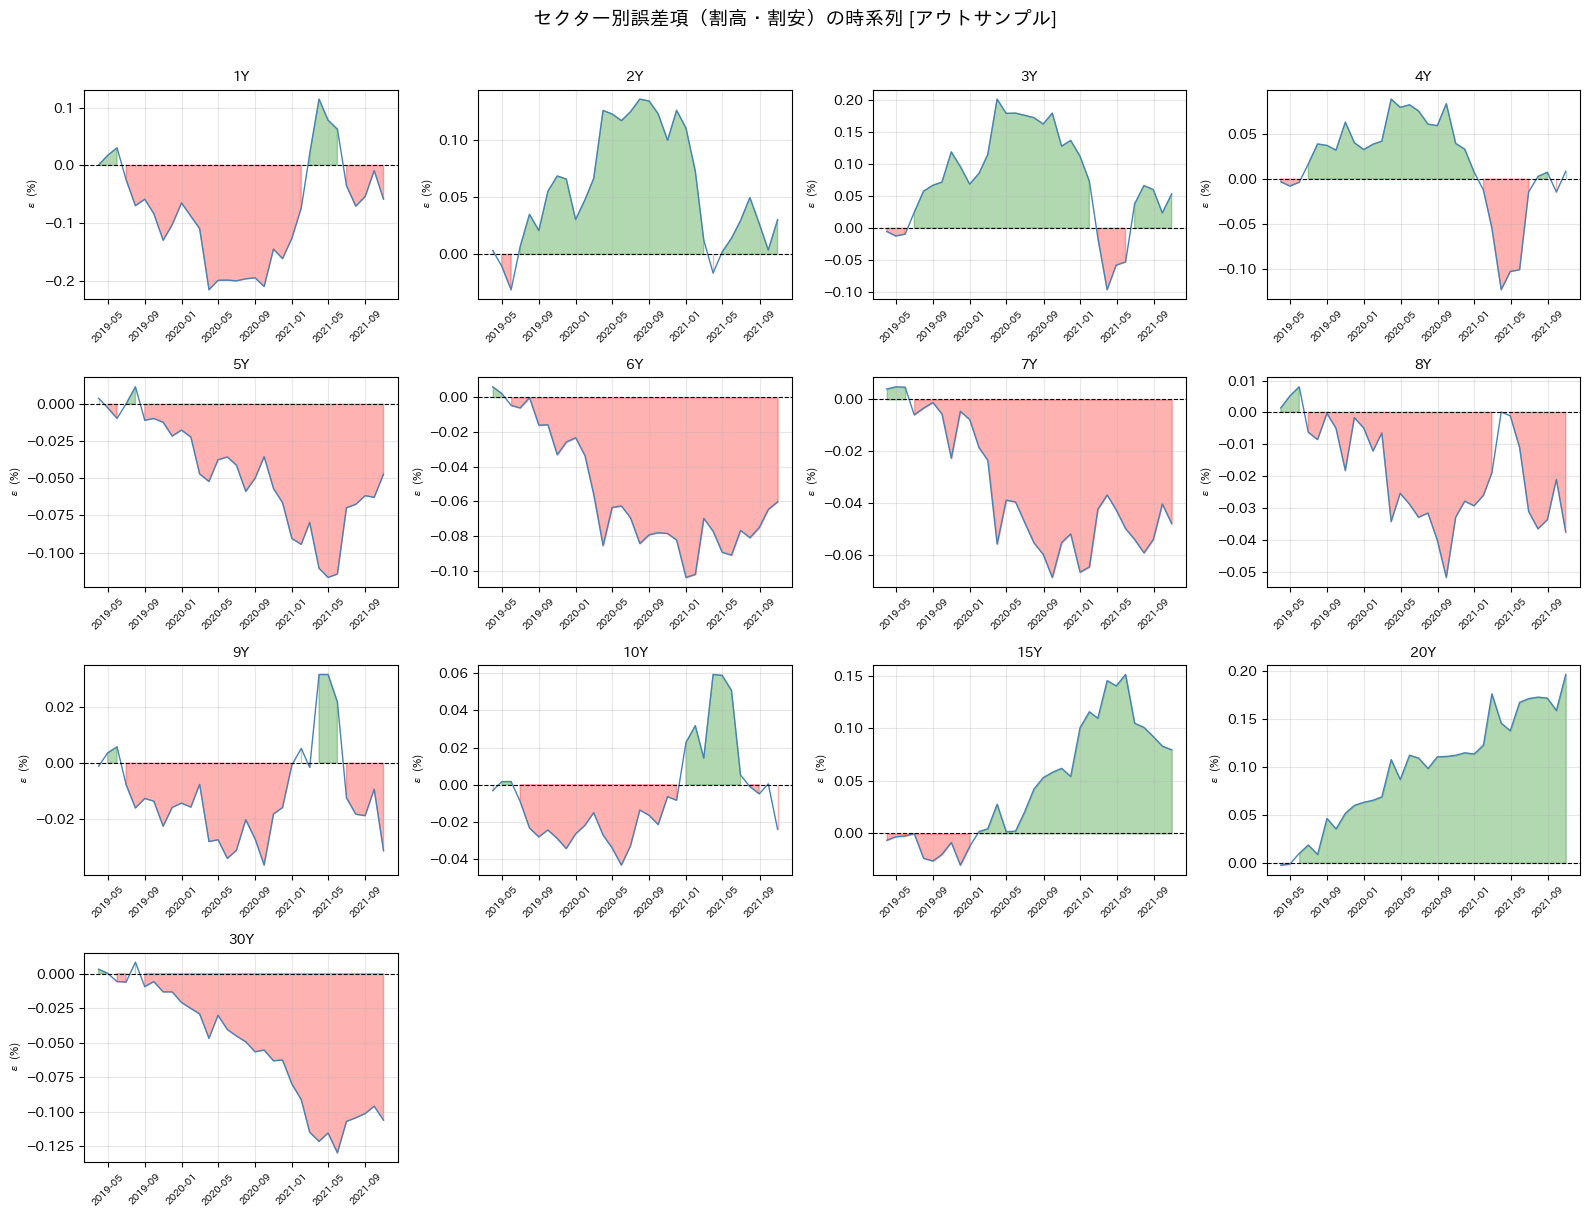

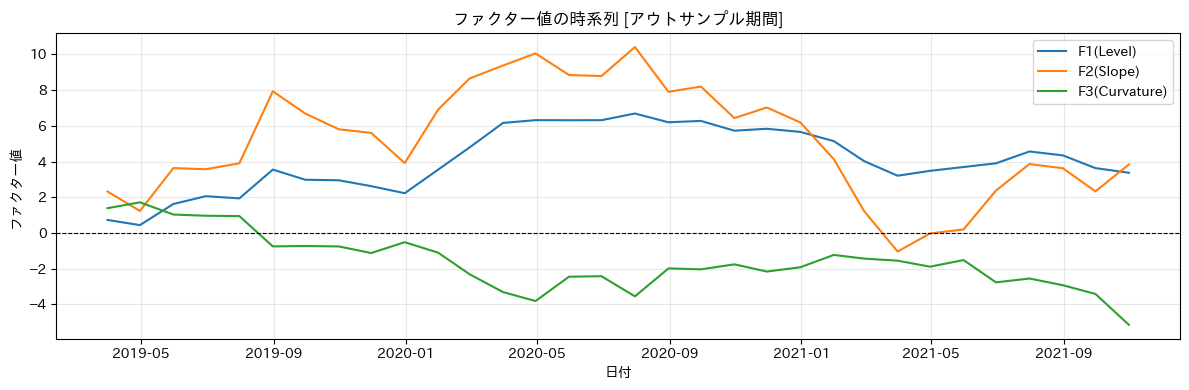

In [14]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, name in enumerate(SECTOR_NAMES):
    axes[i].plot(yields_oos.index, resid_df[name], color='steelblue', linewidth=1)
    axes[i].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[i].fill_between(yields_oos.index, resid_df[name], 0,
                         where=resid_df[name] > 0, alpha=0.3, color='green', label='割安')
    axes[i].fill_between(yields_oos.index, resid_df[name], 0,
                         where=resid_df[name] < 0, alpha=0.3, color='red', label='割高')
    axes[i].set_title(f'{name}', fontsize=10)
    axes[i].set_ylabel('ε (%)', fontsize=8)
    axes[i].tick_params(axis='x', rotation=45, labelsize=7)
    axes[i].grid(True, alpha=0.3)

for i in range(N_SECTORS, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('セクター別誤差項（割高・割安）の時系列 [アウトサンプル]', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
for j, label in enumerate(['F1(Level)', 'F2(Slope)', 'F3(Curvature)']):
    ax.plot(yields_oos.index, factor_vals_oos[:, j], label=label, linewidth=1.5)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('ファクター値の時系列 [アウトサンプル期間]', fontsize=12)
ax.set_xlabel('日付'); ax.set_ylabel('ファクター値')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 第4章: 改良CA&RD戦略

### 4-1: 3種類のシナリオリターンの定義と説明

論文では3種類のシナリオリターンを定義する（5年債の例）:

**(i) 実際の利回りを使用（式3）:**
ロールダウン差分 $\Delta^{(i)} = Y_{0, T-0.5}^{\text{実際}} - Y_{0, T}^{\text{実際}}$

**(ii) 3Fモデル適正利回りを使用（式7）:**
$$\Delta^{\text{model}} = \sum_j a_{T-0.5,j} f_j(0) - \sum_j a_{T,j} f_j(0)$$

**(iii) 誤差項の収束を組み込んだ提案手法（式8）:**
$$\Delta^{\text{adj}} = \sum_j a_{T-0.5,j} f_j(0) - \left( \sum_j a_{T,j} f_j(0) + \gamma \cdot \varepsilon_T(0) \right)$$

**直感:** 割安（$\varepsilon > 0$）なセクターでは誤差が収束する方向（利回り低下）がシナリオに組み込まれ、CA&RDが増加 → 最適化で選ばれやすくなる。

In [15]:
def calc_card_all_scenarios(yields_row, loadings, scaler, f_hat, eps_pct,
                             maturities=MATURITIES, gamma=GAMMA, freq=2):
    """
    1時点の全セクターについて3種類のCA&RDを計算する。
    yields_row: %単位の利回り（13次元）
    loadings:   (13, 3) ファクターローディング（固定）
    scaler:     インサンプルのStandardScaler（固定）
    f_hat:      時点tのファクター値（標準化スケール, shape: 3）
    eps_pct:    時点tの誤差項（%単位, shape: 13）
    gamma:      誤差項修正割合
    Returns: cards_i, cards_ii, cards_iii, durs （各 shape: (13,)）
    """
    y_arr    = np.array(yields_row.values, dtype=float) / 100
    y_pct    = np.array(yields_row.values, dtype=float)
    cs_actual = CubicSpline(maturities, y_pct)

    # 全セクターの3Fモデル適正利回り（%単位）
    y_model_all = (loadings @ f_hat) * scaler.scale_ + scaler.mean_   # (13,)
    cs_model    = CubicSpline(maturities, y_model_all)                  # 適正利回りスプライン

    cards_i, cards_ii, cards_iii, durs = [], [], [], []

    for k, T_i in enumerate(maturities):
        y_i  = y_arr[k]
        T_rd = max(T_i - HOLDING, maturities[0])

        # (i) 実際の利回りによるロールダウン差分 — 式(3)
        delta_i = cs_actual(T_rd) / 100 - y_i

        # (ii) 3Fモデル適正利回りによるロールダウン差分 — 式(7)
        y_model_i  = y_model_all[k]            # T_i年の適正利回り（%単位）
        y_model_rd = cs_model(T_rd)            # T_rd年の適正利回り（%単位、スプライン補間）
        delta_ii   = (y_model_rd - y_model_i) / 100

        # (iii) 誤差項収束を組み込んだロールダウン差分 — 式(8)
        eps_i     = eps_pct[k]                 # %単位
        delta_iii = (y_model_rd - (y_model_i + gamma * eps_i)) / 100

        c_i   = calc_card_taylor(y_i, delta_i,   T_i, freq)
        c_ii  = calc_card_taylor(y_i, delta_ii,  T_i, freq)
        c_iii = calc_card_taylor(y_i, delta_iii, T_i, freq)

        cards_i.append(c_i)
        cards_ii.append(c_ii)
        cards_iii.append(c_iii)
        durs.append(mod_duration(y_i, T_i, freq))

    return np.array(cards_i), np.array(cards_ii), np.array(cards_iii), np.array(durs)


print("CA&RD計算関数（3シナリオ）の定義完了")

CA&RD計算関数（3シナリオ）の定義完了


### 4-2: 各シナリオのCA&RD計算（1時点での確認）

アウトサンプル開始翌月（2019年4月末）を例に、3種類のCA&RDを計算・比較する。

検証日: 2019-04-30


,CA&RD(i) %,CA&RD(ii) %,CA&RD(iii) %,ε_i (%),Δ(iii-i) bp
1Y,1.1950,1.1950,1.2036,0.0174,0.8561
2Y,1.0693,1.0827,1.0752,-0.0102,0.5948
3Y,1.1015,1.0995,1.0848,-0.0122,-1.6700
4Y,1.1472,1.1391,1.1261,-0.0077,-2.1135
5Y,1.2219,1.2105,1.2054,-0.0024,-1.6488
6Y,1.3102,1.2994,1.3049,0.0022,-0.5281
7Y,1.3640,1.3577,1.3722,0.0049,0.8207
8Y,1.3735,1.3745,1.3920,0.0051,1.8498
9Y,1.3792,1.3858,1.3999,0.0037,2.0641
10Y,1.3905,1.3991,1.4061,0.0017,1.5602


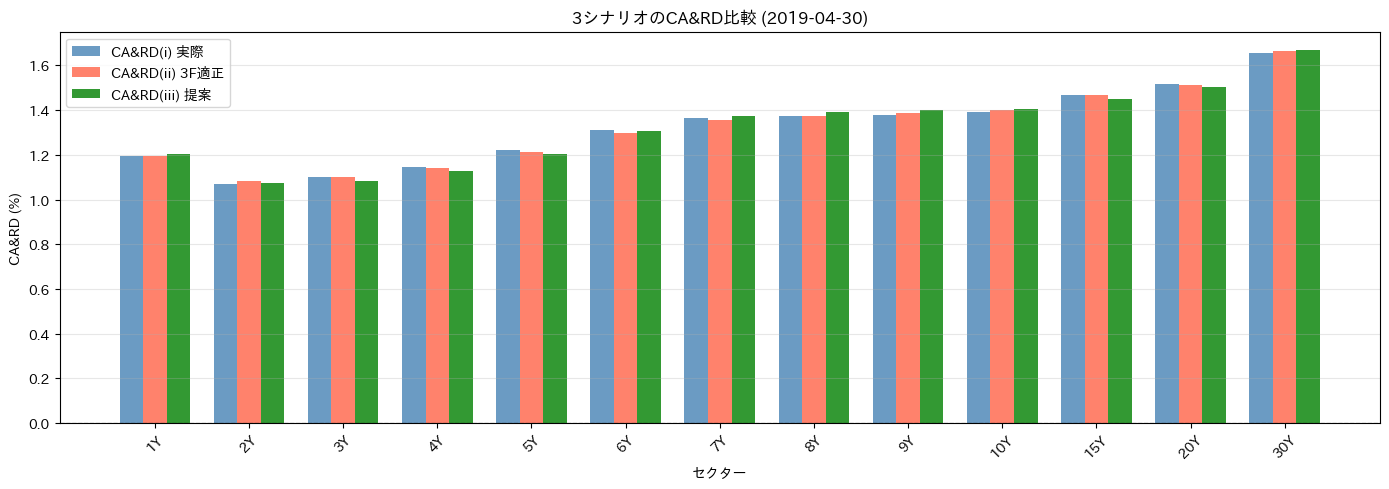

In [16]:
t_check   = 1  # アウトサンプル開始翌月
row_check = yields_oos.iloc[t_check]
f_check   = factor_vals_oos[t_check]
eps_check = residuals_oos[t_check]

c_i, c_ii, c_iii, durs_check = calc_card_all_scenarios(
    row_check, loadings, scaler, f_check, eps_check
)

print(f"検証日: {yields_oos.index[t_check].date()}")
compare_df = pd.DataFrame({
    'CA&RD(i) %':   c_i * 100,
    'CA&RD(ii) %':  c_ii * 100,
    'CA&RD(iii) %': c_iii * 100,
    'ε_i (%)':      eps_check,
    'Δ(iii-i) bp':  (c_iii - c_i) * 10000,
}, index=SECTOR_NAMES)
display(compare_df.round(4))

x = np.arange(N_SECTORS)
width = 0.25
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width, c_i * 100,   width, label='CA&RD(i) 実際',    color='steelblue', alpha=0.8)
ax.bar(x,         c_ii * 100,  width, label='CA&RD(ii) 3F適正', color='tomato',    alpha=0.8)
ax.bar(x + width, c_iii * 100, width, label='CA&RD(iii) 提案',  color='green',     alpha=0.8)
ax.set_title(f'3シナリオのCA&RD比較 ({yields_oos.index[t_check].date()})', fontsize=12)
ax.set_xlabel('セクター'); ax.set_ylabel('CA&RD (%)')
ax.set_xticks(x); ax.set_xticklabels(SECTOR_NAMES, rotation=45)
ax.legend(); ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 4-3: バックテスト（3ポートフォリオ同時）

アウトサンプル期間（2019年3月末〜2021年10月末）に対して、3種類のシナリオを使った月次リバランス・バックテストを実施する。

**先読みバイアス防止の核心:**
- 時点$t$のCA&RDシグナル・最適ウエイト計算には時点$t$のデータのみ使用
- 実現リターンは翌月末$t+1$の実際の利回りで計算（バックテストとして正しい）

In [17]:
def run_backtest_all_scenarios(df_oos, loadings, scaler, fv_all, eps_all,
                               maturities=MATURITIES, gamma=GAMMA, freq=2):
    dates = df_oos.index
    n_p   = len(dates)
    wi_list, wii_list, wiii_list = [], [], []
    ri, rii, riii, rbm = [], [], [], []

    for t in range(n_p - 1):
        row_t  = df_oos.iloc[t]    # シグナル（先読みなし）
        row_t1 = df_oos.iloc[t+1]  # 実現リターン（実現値）

        f_t   = fv_all[t]
        eps_t = eps_all[t]
        c_i, c_ii, c_iii, durs_t = calc_card_all_scenarios(
            row_t, loadings, scaler, f_t, eps_t, maturities, gamma, freq
        )
        w_bm = np.ones(N_SECTORS) / N_SECTORS
        D_bm = np.dot(w_bm, durs_t)

        w_i   = optimize_portfolio(c_i,   durs_t, D_bm)
        w_ii  = optimize_portfolio(c_ii,  durs_t, D_bm)
        w_iii = optimize_portfolio(c_iii, durs_t, D_bm)
        wi_list.append(w_i); wii_list.append(w_ii); wiii_list.append(w_iii)

        y_arr_t  = np.array(row_t.values,  dtype=float) / 100
        y_pct_t1 = np.array(row_t1.values, dtype=float)
        cs_t1    = CubicSpline(maturities, y_pct_t1)

        realized = []
        for k, T_i in enumerate(maturities):
            T_rd = max(T_i - HOLDING, maturities[0])
            y_rd = cs_t1(T_rd) / 100
            r    = calc_realized_return_sector(y_arr_t[k], y_rd, T_i, freq)
            realized.append(r)
        realized = np.array(realized)

        ri.append(np.dot(w_i,   realized))
        rii.append(np.dot(w_ii,  realized))
        riii.append(np.dot(w_iii, realized))
        rbm.append(np.dot(w_bm,  realized))

    idx = dates[1:]
    return (
        pd.Series(ri,   index=idx, name='CA&RD(i)'),
        pd.Series(rii,  index=idx, name='CA&RD(ii)'),
        pd.Series(riii, index=idx, name='CA&RD(iii)'),
        pd.Series(rbm,  index=idx, name='BM'),
        pd.DataFrame(wi_list,   index=dates[:-1], columns=SECTOR_NAMES),
        pd.DataFrame(wii_list,  index=dates[:-1], columns=SECTOR_NAMES),
        pd.DataFrame(wiii_list, index=dates[:-1], columns=SECTOR_NAMES),
    )


print("3シナリオ同時バックテスト実行中...")
port_i, port_ii, port_iii, bm_ret2, w_i, w_ii, w_iii = run_backtest_all_scenarios(
    yields_oos, loadings, scaler, factor_vals_oos, residuals_oos
)
print(f"バックテスト完了: {len(port_i)}ヶ月分")

3シナリオ同時バックテスト実行中...
バックテスト完了: 31ヶ月分


### 4-4: パフォーマンス比較表（論文 表1の再現）

3種類のポートフォリオとベンチマークのパフォーマンス指標を計算し、論文の表1と比較する。

**論文の目標値（参考）:**

| ポートフォリオ | 超過リターン | TE | IR | 勝率 |
|---|---|---|---|---|
| ①CA&RD（実際利回り） | ~0.19% | ~0.78% | ~0.24 | ~61% |
| ②CA&RD(model) | ~0.01% | ~0.75% | ~0.02 | ~55% |
| **③CA&RD+α(model)（提案手法）** | **~0.67%** | **~0.61%** | **~1.10** | **~71%** |

In [18]:
alpha_i   = port_i   - bm_ret2
alpha_ii  = port_ii  - bm_ret2
alpha_iii = port_iii - bm_ret2

def make_perf_row(port_ret, bm_r, name):
    alpha = port_ret - bm_r
    return pd.Series({
        'ポートフォリオリターン (%)': annualize_return(port_ret) * 100,
        '超過リターン (%)':          annualize_return(alpha) * 100,
        'TE (%)':                   calc_tracking_error(alpha) * 100,
        'IR':                       calc_information_ratio(alpha),
        '勝率 (%)':                  calc_win_rate(alpha) * 100,
    }, name=name)

bm_ann = annualize_return(bm_ret2) * 100

results = pd.DataFrame([
    make_perf_row(port_i,   bm_ret2, '①CA&RD（実際利回り）'),
    make_perf_row(port_ii,  bm_ret2, '②CA&RD(model)（3F適正）'),
    make_perf_row(port_iii, bm_ret2, '③CA&RD+α(model)（提案手法）'),
]).T

print(f"=== パフォーマンス比較表（論文 表1の再現）===")
print(f"ベンチマーク年率リターン: {bm_ann:.2f}%")
print()
display(results.round(4))

print()
print("【論文値との比較（目標値）】")
print("              超過リターン  TE     IR    勝率")
print("① CA&RD実際:    0.19%     0.78%  0.24  61%")
print("② CA&RD model:  0.01%     0.75%  0.02  55%")
print("③ CA&RD+α:      0.67%     0.61%  1.10  71%")

=== パフォーマンス比較表（論文 表1の再現）===
ベンチマーク年率リターン: 12.11%



,①CA&RD（実際利回り）,②CA&RD(model)（3F適正）,③CA&RD+α(model)（提案手法）
ポートフォリオリターン (%),14.1040,12.6994,13.2062
超過リターン (%),1.9907,0.5862,1.0929
TE (%),0.6355,0.6417,0.6491
IR,3.1325,0.9135,1.6837
勝率 (%),83.8710,48.3871,67.7419



【論文値との比較（目標値）】
              超過リターン  TE     IR    勝率
① CA&RD実際:    0.19%     0.78%  0.24  61%
② CA&RD model:  0.01%     0.75%  0.02  55%
③ CA&RD+α:      0.67%     0.61%  1.10  71%


### 4-5: 累積超過リターンの可視化

3種類のポートフォリオの累積超過リターンと累積リターン推移を可視化する。論文では提案手法（③）が①を約135BP上回ることが示されている。

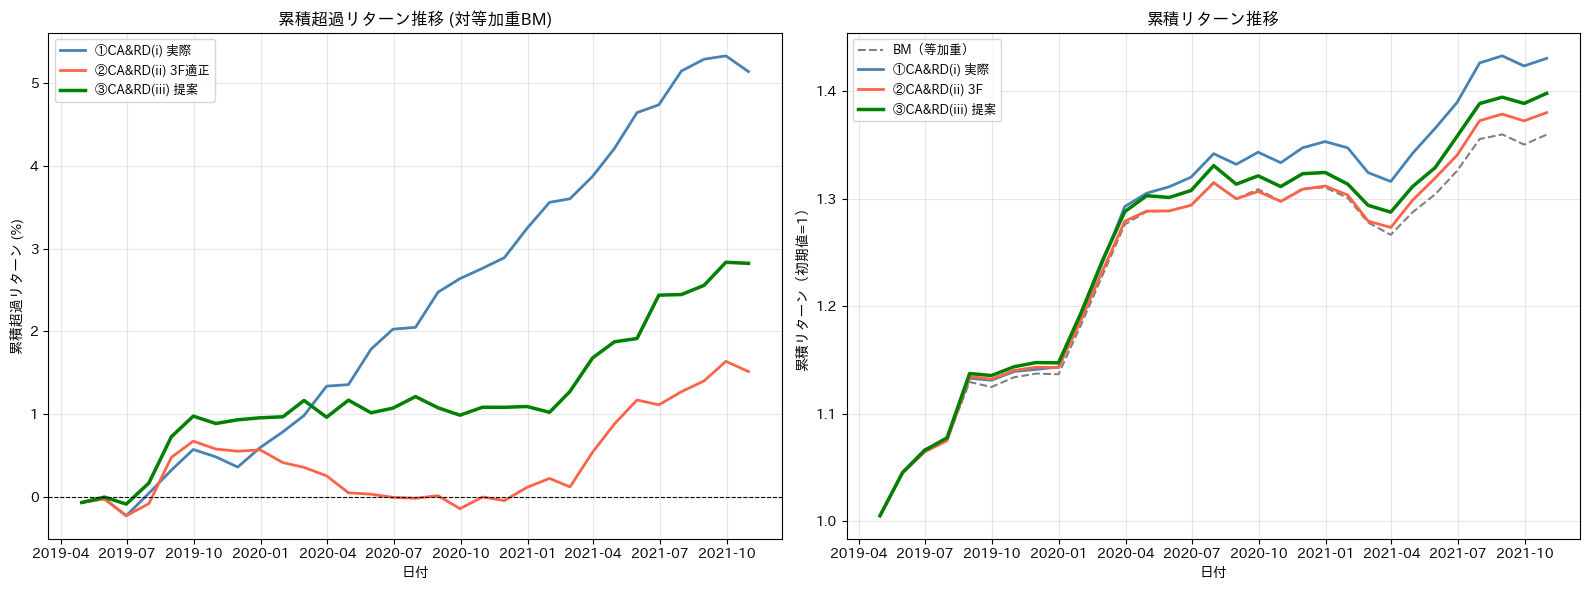

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cum_a_i   = alpha_i.cumsum() * 100
cum_a_ii  = alpha_ii.cumsum() * 100
cum_a_iii = alpha_iii.cumsum() * 100

axes[0].plot(cum_a_i.index,   cum_a_i.values,   label='①CA&RD(i) 実際',   color='steelblue', linewidth=2)
axes[0].plot(cum_a_ii.index,  cum_a_ii.values,  label='②CA&RD(ii) 3F適正', color='tomato',    linewidth=2)
axes[0].plot(cum_a_iii.index, cum_a_iii.values, label='③CA&RD(iii) 提案', color='green',     linewidth=2.5)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('累積超過リターン推移 (対等加重BM)', fontsize=12)
axes[0].set_xlabel('日付'); axes[0].set_ylabel('累積超過リターン (%)')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

cum_bm    = (1 + bm_ret2).cumprod()
cum_p_i   = (1 + port_i).cumprod()
cum_p_ii  = (1 + port_ii).cumprod()
cum_p_iii = (1 + port_iii).cumprod()

axes[1].plot(cum_bm.index,    cum_bm.values,    label='BM（等加重）',      color='gray',       linewidth=1.5, linestyle='--')
axes[1].plot(cum_p_i.index,   cum_p_i.values,   label='①CA&RD(i) 実際',  color='steelblue',  linewidth=2)
axes[1].plot(cum_p_ii.index,  cum_p_ii.values,  label='②CA&RD(ii) 3F',   color='tomato',     linewidth=2)
axes[1].plot(cum_p_iii.index, cum_p_iii.values, label='③CA&RD(iii) 提案', color='green',     linewidth=2.5)
axes[1].set_title('累積リターン推移', fontsize=12)
axes[1].set_xlabel('日付'); axes[1].set_ylabel('累積リターン（初期値=1）')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4-6: ウエイト推移の可視化

3種類のポートフォリオのウエイト推移を積み上げグラフで可視化する。

論文の予測:
- ①（CA&RD実際）: ほぼ全期間で**ブレット型**（6〜7年債中心）
- ③（提案手法）: 割安セクターが強調され**バーベル型**（短期＋超長期）になりやすい

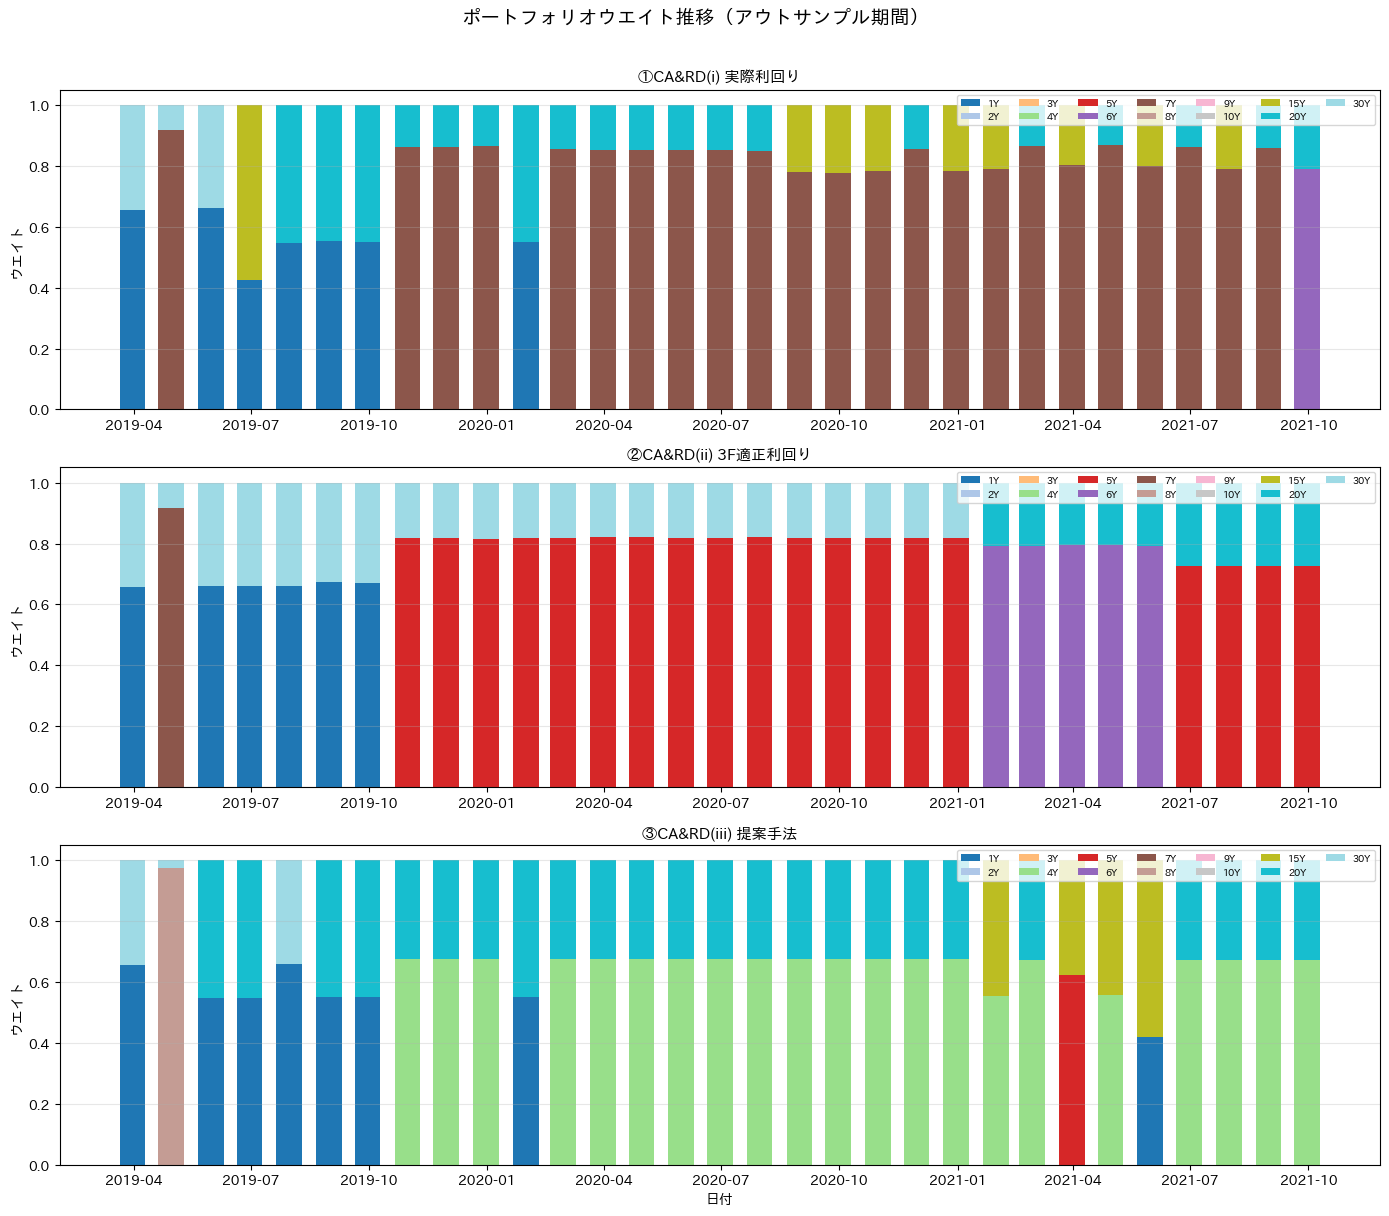

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
colors_s = plt.cm.tab20(np.linspace(0, 1, N_SECTORS))

for (w_df, title, ax) in [
    (w_i,   '①CA&RD(i) 実際利回り',    axes[0]),
    (w_ii,  '②CA&RD(ii) 3F適正利回り', axes[1]),
    (w_iii, '③CA&RD(iii) 提案手法',    axes[2]),
]:
    bottom = np.zeros(len(w_df))
    for k, name in enumerate(SECTOR_NAMES):
        ax.bar(w_df.index, w_df[name].values, bottom=bottom,
               label=name, color=colors_s[k], width=20)
        bottom += w_df[name].values
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('ウエイト'); ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(loc='upper right', ncol=7, fontsize=7)

axes[2].set_xlabel('日付')
plt.suptitle('ポートフォリオウエイト推移（アウトサンプル期間）', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 4-7: 分散分解分析（論文 表2の再現）

論文の式(9)(10)に基づき、各セクターの利回り分散を「3Fモデル説明部分」と「誤差項部分」に分解する。

$$\text{Var}(Y_i) = \underbrace{B}_{3F分散} + \underbrace{\text{Var}(\varepsilon_i)}_{誤差項分散} + 2\text{Cov}(\cdot) \tag{10}$$

**判定指標 $C/A$:**
- $C/A > 100\%$: 負の共分散 → 市場セルオフ時にアウトパフォームしやすい
- $C/A < 100\%$: 正の共分散 → 市場セルオフ時にアンダーパフォームしやすい

=== 分散分解分析（論文 表2の再現）===


,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y,15Y,20Y,30Y
A 実際の金利の分散,0.7533,0.6005,0.5114,0.4453,0.3961,0.3592,0.3325,0.3160,0.3057,0.2982,0.2638,0.2311,0.2067
B 3Fの金利の分散,0.7226,0.6419,0.5562,0.4536,0.3685,0.3255,0.3096,0.3020,0.2967,0.2923,0.2716,0.2512,0.2008
誤差項の分散,0.0082,0.0026,0.0061,0.0028,0.0013,0.0011,0.0006,0.0002,0.0003,0.0007,0.0032,0.0033,0.0019
C = B + 誤差項分散,0.7309,0.6445,0.5622,0.4564,0.3697,0.3267,0.3102,0.3022,0.2970,0.2930,0.2748,0.2545,0.2027
C/A (%),97.0197,107.3251,109.9427,102.4970,93.3421,90.9428,93.2783,95.6484,97.1608,98.2610,104.1807,110.1136,98.0509


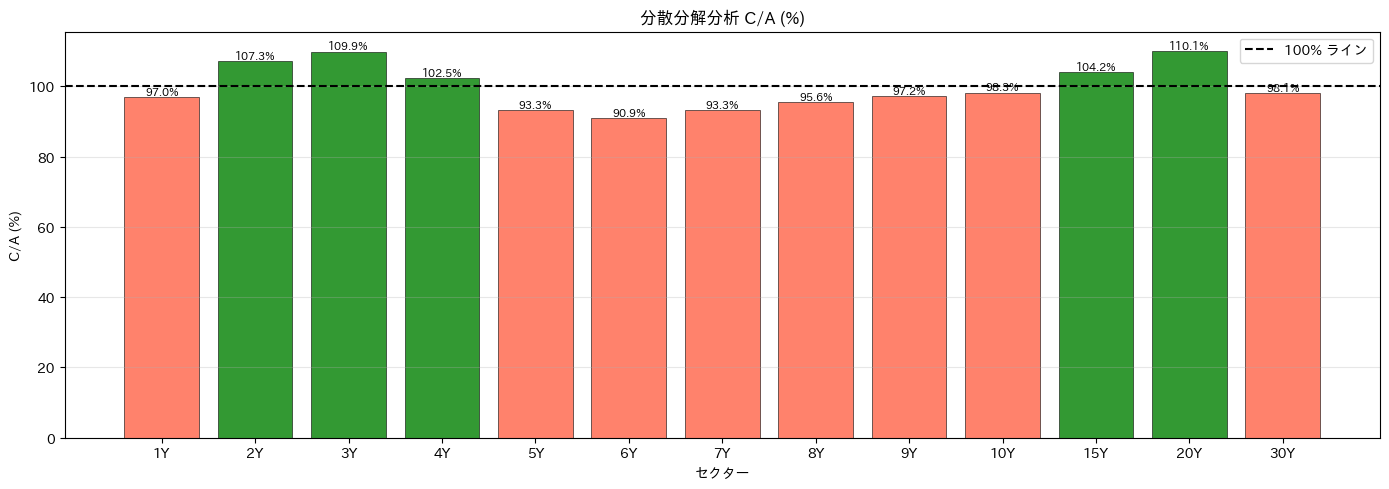


【論文表2との比較（目標値）】
セクター:  1Y    2Y    3Y    4Y    5Y    6Y    7Y    8Y    9Y   10Y   15Y   20Y   30Y
論文C/A:  102.1 101.7 100.2  98.1  96.5  96.8  96.8  97.7  99.0  99.9 102.2 104.4  98.5
本実装:    97.0 107.3 109.9 102.5  93.3  90.9  93.3  95.6  97.2  98.3 104.2 110.1  98.1


In [21]:
y_actual  = yields_oos.values.astype(float)
y_model_a = y_model_oos
eps_a     = residuals_oos

var_A = np.var(y_actual,  axis=0, ddof=1)
var_B = np.var(y_model_a, axis=0, ddof=1)
var_e = np.var(eps_a,     axis=0, ddof=1)
var_C = var_B + var_e
C_A   = var_C / var_A * 100

var_df = pd.DataFrame({
    'A 実際の金利の分散':  var_A,
    'B 3Fの金利の分散':    var_B,
    '誤差項の分散':         var_e,
    'C = B + 誤差項分散':  var_C,
    'C/A (%)':             C_A,
}, index=SECTOR_NAMES).T

print("=== 分散分解分析（論文 表2の再現）===")
display(var_df.round(4))

fig, ax = plt.subplots(figsize=(14, 5))
bar_colors = ['green' if v > 100 else 'tomato' for v in C_A]
ax.bar(SECTOR_NAMES, C_A, color=bar_colors, alpha=0.8, edgecolor='black', linewidth=0.5)
ax.axhline(100, color='black', linewidth=1.5, linestyle='--', label='100% ライン')
ax.set_title('分散分解分析 C/A (%)', fontsize=12)
ax.set_xlabel('セクター'); ax.set_ylabel('C/A (%)')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(C_A):
    ax.text(i, v + 0.1, f'{v:.1f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

print("\n【論文表2との比較（目標値）】")
print("セクター:  1Y    2Y    3Y    4Y    5Y    6Y    7Y    8Y    9Y   10Y   15Y   20Y   30Y")
print("論文C/A:  102.1 101.7 100.2  98.1  96.5  96.8  96.8  97.7  99.0  99.9 102.2 104.4  98.5")
print(f"本実装:  ", " ".join([f"{v:5.1f}" for v in C_A]))

---
## 第5章: まとめ

本ノートブックで実施した内容と主要な発見をまとめる。

In [22]:
print("="*65)
print("実装まとめ: 因子分析に基づく米国債キャリーロールダウン戦略")
print("="*65)

print("\n【論文表1相当 パフォーマンス指標】")
print(f"{'ポートフォリオ':<25} {'超過R(%)':>8} {'TE(%)':>7} {'IR':>6} {'勝率(%)':>8}")
print("-" * 60)
for port_r, bm_r, name in [
    (port_i,   bm_ret2, '①CA&RD（実際利回り）'),
    (port_ii,  bm_ret2, '②CA&RD(model)'),
    (port_iii, bm_ret2, '③CA&RD+α(model)提案'),
]:
    alp = port_r - bm_r
    ar  = annualize_return(alp) * 100
    te  = calc_tracking_error(alp) * 100
    ir  = calc_information_ratio(alp)
    wr  = calc_win_rate(alp) * 100
    print(f"  {name:<23} {ar:>8.3f} {te:>7.3f} {ir:>6.3f} {wr:>8.2f}")

print()
print("【論文値（参考）】")
print("  ①CA&RD実際:           0.190   0.780  0.240    61.29")
print("  ②CA&RD model:          0.010   0.750  0.020    54.84")
print("  ③CA&RD+α(model):       0.670   0.610  1.100    70.97")

print()
print("【3因子モデル説明率】")
print(f"  インサンプル全体説明率: {explain_pct:.2f}%")

print()
print("【今後の課題】")
print("  (Ⅰ) 分析期間の拡充（過去20年程度の長期実証分析が必要）")
print("  (Ⅱ) γの最適化（本実装では論文設定値 γ=0.5 を使用）")
print("  (Ⅲ) ファクターローディングの更新頻度検討（本実装では固定）")
print("  (Ⅳ) 取引コストの考慮")

実装まとめ: 因子分析に基づく米国債キャリーロールダウン戦略

【論文表1相当 パフォーマンス指標】
ポートフォリオ                     超過R(%)   TE(%)     IR    勝率(%)
------------------------------------------------------------
  ①CA&RD（実際利回り）              1.991   0.636  3.132    83.87
  ②CA&RD(model)              0.586   0.642  0.913    48.39
  ③CA&RD+α(model)提案          1.093   0.649  1.684    67.74

【論文値（参考）】
  ①CA&RD実際:           0.190   0.780  0.240    61.29
  ②CA&RD model:          0.010   0.750  0.020    54.84
  ③CA&RD+α(model):       0.670   0.610  1.100    70.97

【3因子モデル説明率】
  インサンプル全体説明率: 99.70%

【今後の課題】
  (Ⅰ) 分析期間の拡充（過去20年程度の長期実証分析が必要）
  (Ⅱ) γの最適化（本実装では論文設定値 γ=0.5 を使用）
  (Ⅲ) ファクターローディングの更新頻度検討（本実装では固定）
  (Ⅳ) 取引コストの考慮
